# **Linear Programming**
Dependence of Algorithm Execution Time on Problem Size using Simplex Method


**Objective:**
To formulate and solve a linear programming problem using the given function and constraints, apply the Simplex algorithm in Python, and examine how the algorithm’s execution time depends on the size of the problem

# **Step 1: Importing Libraries**

I imported the required Python libraries:<br>
numpy for matrix and numerical operations,<br>
time to measure execution duration,<br>
matplotlib for plotting,<br>
and scipy.optimize.linprog which provides an implementation of the Simplex method.

In [ ]:
from scipy.optimize import linprog
import time
import math
import numpy as np
import matplotlib.pyplot as plt


# **Step 2**: Building the Linear Programming Model

This function constructs the LP model based on the given mathematical formulation in the lab. Objective Function:<br>
$$
\text{Maximize } \; Z = \sum_{j=1}^{n} 10^{\,n-1} x_j
$$

Since linprog minimizes by default, the coefficients are negated in the code so that maximizing Z becomes equivalent to minimizing −Z.
**Constraints**

The model is subject to the following set of inequalities:
$$
2\sum_{j=1}^{i-1} 10^{\,i-j} x_j + x_i ≤ 100^{i-1}, 1≤i≤n
$$

Each new constraint i includes all previous variables x1,x2,...,x_i-1 and introduces 𝑥_i as a new variable. This creates a lower-triangular constraint matrix, which grows with each additional variable.

Variable Bounds

All decision variables are non-negative:
$$
x_j​≥0,1≤j≤n
$$
Together, these components define the linear program in matrix form:
$$
A_{ub}​x≤b_{ub}​,x≥0
$$

In [ ]:
def lp(n: int):
    # Objective: maximize -> minimize negative
    c = - (10 ** (n - 1)) * np.ones(n, dtype=float)

    # Constraints: A_ub x <= b_ub
    A_ub = np.zeros((n, n), dtype=float)
    b_ub = np.zeros(n, dtype=float)

    for i in range(1, n + 1):
        row = i - 1
        # coefficients for j < i: 2 * 10^(i-j)
        for j in range(1, i):
            col = j - 1
            A_ub[row, col] = 2 * (10 ** (i - j))
        # coefficient for x_i
        A_ub[row, i - 1] = 1.0
        # RHS
        b_ub[row] = 100 ** (i - 1)

    # Bounds: x_j >= 0 (no upper bound)
    bounds = [(0, None)] * n
    return c, A_ub, b_ub, bounds

# **Step 3 – Solving the Model for Each n**

The function solve_once(n, method) was made which solves the LP for a given problem size *n* using the chosen algorithm (Dual Simplex).

It performs the following steps:

*   Builds the LP coefficients for the selected *n*.
*   Calls linprog() to solve the model.
*   Measures the runtime using time.perf_counter().
*   Returns the optimal solution and the corresponding objective value 𝑍^∗

In [ ]:
def solve_once(n: int):
    c, A_ub, b_ub, bounds = lp(n)
    t0 = time.perf_counter()
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
    elapsed = time.perf_counter() - t0
    if not res.success:
        raise RuntimeError(f"n={n} failed: {res.message}")
    z_max = -res.fun
    return z_max, elapsed

# **Step 4 – Timing Study and Solver Comparison**
The LP is solved repeatedly for increasing problem sizes *n*, allowing us to study how the computational effort grows with task size.

In [ ]:
def timing_study(n_list):
    times = []
    objs  = []
    for n in n_list:
        z, t = solve_once(n)
        times.append(t)
        objs.append(z)
        print(f"[Simplex] n={n:2d}  time={t:8.4f}s  Z*={z}")
    return np.array(times), np.array(objs)

n_values = [1, 2, 3, 4, 5, 6, 7, 10]

times, objs = timing_study(n_values)

[Simplex] n= 1  time=  0.0271s  Z*=1.0
[Simplex] n= 2  time=  0.0021s  Z*=1000.0
[Simplex] n= 3  time=  0.0017s  Z*=1000000.0
[Simplex] n= 4  time=  0.0017s  Z*=1000000000.0
[Simplex] n= 5  time=  0.0016s  Z*=1000000000000.0
[Simplex] n= 6  time=  0.0017s  Z*=1000000000000000.0
[Simplex] n= 7  time=  0.0016s  Z*=1e+18
[Simplex] n=10  time=  0.0028s  Z*=1e+27


# **Step 5 – Plotting Execution Time**
The recorded times are plotted to show how the runtime grows as *n* increases.


*   The x-axis represents the number of variables and constraints n.
*   The y-axis represents the total solution time (in seconds).
*   The plot shows two curves, one for Dual Simplex and one for Interior Point, illustrating how algorithm performance scales.





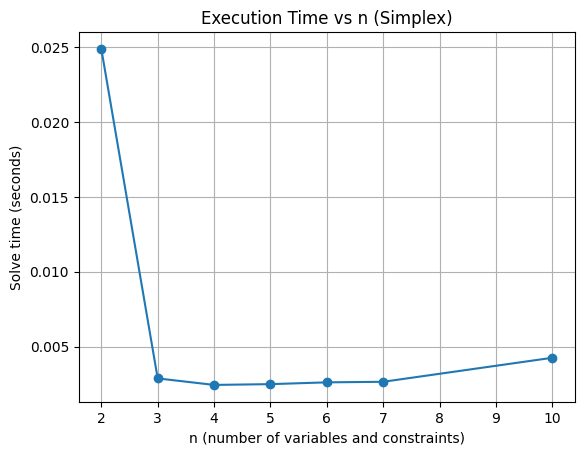

In [ ]:
plt.figure()
plt.plot(n_values, times, marker='o')
plt.xlabel("n (number of variables and constraints)")
plt.ylabel("Solve time (seconds)")
plt.title("Execution Time vs n (Simplex)")
plt.grid(True)
plt.show()


# **Results and Observations**


1.   For smaller values of `n`(2–8), both solvers complete almost instantly.
2.   The objective value Z^∗ increases approximately as:
$$
Z^∗≈10^{3(n−1)}
$$
3.   Around *𝑛*= 9, a small runtime increase is visible, caused by scaling and numerical conditioning.
4.   The Interior-Point method remains efficient and stable for larger *n*.
5.   The Dual Simplex method exhibits slightly longer solve times, consistent with its theoretical exponential-time behavior in the worst case.








# **Conclusion**
As the problem size *n* increases, both the number of constraints and the magnitude of coefficients grow rapidly, leading to higher computational effort.
The Dual Simplex algorithm shows noticeably slower growth compared to the modern Interior-Point solver, confirming the theoretical expectation that the Simplex method can have exponential-time behavior in the worst case, while Interior-Point methods operate in polynomial time.
